In [1]:
%matplotlib widget

# Planck spectroscopy

The goal of this Notebook is to present the measurements done to calibrate the signal output line of the JPA meaasurement setup, which is presented in the next figure.

The amplifiers on the output line add classical noise which ruins the possible quantum correlations generated by the JPA. Given the gain ($G$) and added noise ($\bar{n}$) of the amplifiers, the quantum statistics in the covariance matrix can be reconstructed.

In order to get $G$ and $\bar{n}$ we measure the noise power (Johnson-Nyquist noise) emitted by the $20$ dB attenuator in the mixing chamber as a function of temperature. 

The power spectral density emitted from a matched resistor ($R=50 \; \Omega$) as a function of temperature is:

$$ P = \dfrac{hf}{2} \text{coth} \left( \dfrac{hf}{2k_BT} \right).$$

As mentioned, our amplification chain scales this noise by $G$ and adds an average number of photons $\bar{n}$ 

$$ P' = G \dfrac{hf}{2} \left[ \text{coth} \left( \dfrac{hf}{2k_BT} \right) + 2\bar{n} + 1 \right].$$

In terms of the voltage variance over a measurement bandwith ($\Delta$) we have:

$$ \left< V^2 \right> = 4 \Delta R P = 2 \Delta G hf R \left[ \text{coth} \left( \dfrac{hf}{2k_BT} \right) + 2\bar{n} + 1 \right].$$

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import h5py
import os
import ipywidgets as widgets
import pandas as pd
import csv
import warnings

from tqdm import tqdm
from datetime import datetime
from scipy.constants import Planck, Boltzmann
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, Data, RealData

warnings.filterwarnings("ignore", category=DeprecationWarning) 

plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['legend.frameon'] = False

plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"

In [3]:
# Thermal noise function for curve_fit fit
def thermal_noise_func(temperature, gain_signal, ns, f_signal, df):
    
    # transmission line impedence
    Zc = 50

    # signal gain in linear scale
    Gs = 10 ** np.abs(gain_signal / 10)

    # conversion factor
    factor_signal = 2 * Zc * Planck * f_signal * df * Gs

    # thermal noise V²
    V2 = factor_signal * (
        1 / np.tanh(Planck * f_signal / (2 * Boltzmann * temperature * 1e-3))
        + (2 * ns + 1)
    ) * 1e12

    return V2


# Thermal noise function for odr fit
def thermal_noise_func_odr(beta, temperature, f_signal, df):
    
    # transmission line impedence
    Zc = 50

    # signal gain in linear scale
    Gs = 10 ** np.abs(beta[0] / 10)

    # conversion factor
    factor_signal = 2 * Zc * Planck * f_signal * df * Gs

    # thermal noise V²
    V2 = factor_signal * (
        1 / np.tanh(Planck * f_signal / (2 * Boltzmann * temperature * 1e-3))
        + (2 * beta[1] + 1)
    ) * 1e12

    return V2

## Error analysis on the calibration data

We measure $N_{pix} = 2.5 \cdot 10^6$ pixels in total, whose mean and standard deviation is given by:

$$ \overline{FS}_{all} = \dfrac{1}{N_{pix}} \sum_i^{N_{pix}} FS_i $$
$$ \sigma_{FS_{all}} = \sqrt{ \dfrac{1}{N_{pix}} \sum_i^{N_{pix}} \left( FS_i - \overline{FS}_{all} \right)^2}$$

The standard deviation of the whole sample is not a good magnitude to characterize the error of the noise. Thus we chunck the data in $N_{chuncks}=1000$ chuncks of $N_{pix,c}=2500$ pixels each. We then calculate the mean and standard deviation of each chunk as:

$$ \overline{FS}_{c} = \dfrac{1}{N_{pix,c}} \sum_i^{N_{pix,c}} FS_i^c $$
$$ \sigma_{FS_{c}} = \sqrt{ \dfrac{1}{N_{pix,c}} \sum_i^{N_{pix,c}} \left( FS_i^c - \overline{FS}_{c} \right)^2}$$

Eventually, we calculate the standard error of the mean as:

$$ \overline{FS} = \dfrac{1}{N_{chuncks}} \sum_c^{N_{chuncks}} \overline{FS}_{c} $$
$$ \sigma_{FS} = \dfrac{1}{\sqrt{N_{chuncks}}} \sum_c^{N_{chunks}} \dfrac{\sigma_{FS}}{N_{chunks}}$$


In [4]:
# Load the raw calibration data 

# Set to True to load and process raw files (takes ~6 hour)
load = False

if load:

    # Load calibration data
    folder = r'/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/JPA/'
    filenames = sorted(
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )
    file_path = [os.path.join(folder, f) for f in filenames]

    # data empty arrays
    noise_fs = np.zeros((len(file_path), 191))
    noise_fs_std = np.zeros_like(noise_fs)
    noise_uV2 = np.zeros_like(noise_fs)
    noise_uV2_std = np.zeros_like(noise_fs)

    noise_fs_i = np.zeros((1000, 191))
    noise_fs_std_i = np.zeros_like(noise_fs_i)
    noise_uV2_i = np.zeros_like(noise_fs_i)
    noise_uV2_std_i = np.zeros_like(noise_fs_i)

    # Temperature arrays (1D: one stable MXC temperature per file)
    temp_arr = np.zeros(len(file_path))
    temp_std_arr = np.zeros_like(temp_arr)

    # Display nice progress bar
    with tqdm(total=len(file_path), ncols=80) as pbar:

        for file_idx, fp in enumerate(file_path):

            pbar.set_description(os.path.basename(fp))
            try:
                hf = h5py.File(fp, 'r')
            except OSError as e:
                print(f'Cannot open: {fp}')
                print(f'  Error: {e}')
                pbar.update(1)
                continue

            with hf as dataset:

                # Navigate HDF5 hierarchy: "Planck Spectroscopy/{myrun}/..."
                sample_grp = dataset["Planck Spectroscopy"]
                myrun = list(sample_grp.keys())[0]
                run_grp = sample_grp[myrun]

                # Integration bandwidth
                fNCO = 4.1e9
                df = 1e3  # Hz, fixed integration bandwidth

                # MXC temperature saved during measurement (mK)
                temp_arr[file_idx] = float(np.real(np.asarray(run_grp['temperature'])))

                # Frequency comb
                freqs = np.asarray(run_grp['freq comb'])
                IF_usb = freqs - fNCO
                IF_lsb = fNCO - freqs
                freq_arr = np.concatenate((np.flipud(IF_lsb[1:]), IF_usb)) + fNCO

                # Raw data
                usb_arr = np.asarray(run_grp['USB'])
                lsb_arr = np.asarray(run_grp['LSB'])
                sb_arr = np.concatenate((np.fliplr(lsb_arr[:,1:]), usb_arr), axis=1)
                Npix = usb_arr.shape[0]

                # Noise power data in uFS^2 (chunked statistics)
                N_chunk = 2500
                i = 0
                for n in range(0, Npix, N_chunk):
                    noise_fs_i[i] = np.mean(np.abs(sb_arr[n:n + N_chunk])**2, axis=0) * 1e12
                    noise_fs_std_i[i] = np.std(np.abs(sb_arr[n:n + N_chunk])**2, axis=0) * 1e12

                    # Noise power in uV^2
                    noise_dBFS = 20 * np.log10(np.mean(np.abs(sb_arr[n:n + N_chunk]), axis=0))
                    noise_dBm = noise_dBFS + 10.67
                    noise_W = 10**((noise_dBm - 30) / 10)
                    noise_V2 = noise_W * 50
                    noise_uV2_i[i] = noise_V2 * 1e12

                    # Standard deviation in uV^2
                    noise_dBFS_std = 20 * np.log10(np.std(np.abs(sb_arr[n:n + N_chunk]), axis=0))
                    noise_dBm_std = noise_dBFS_std + 10.67
                    noise_W_std = 10**((noise_dBm_std - 30) / 10)
                    noise_V2_std = noise_W_std * 50
                    noise_uV2_std_i[i] = noise_V2_std * 1e12

                    i += 1

                noise_fs[file_idx] = np.mean(noise_fs_i, axis=0)
                noise_fs_std[file_idx] = np.mean(noise_fs_std_i, axis=0) / np.sqrt(1000)
                noise_uV2[file_idx] = np.mean(noise_uV2_i, axis=0)
                noise_uV2_std[file_idx] = np.mean(noise_uV2_std_i, axis=0) / np.sqrt(1000)

            pbar.update(1)

    # Sort by ascending MXC temperature
    temp_idx = np.argsort(temp_arr)
    temp_arr      = temp_arr[temp_idx]
    temp_std_arr  = temp_std_arr[temp_idx]
    noise_fs      = noise_fs[temp_idx]
    noise_fs_std  = noise_fs_std[temp_idx]
    noise_uV2     = noise_uV2[temp_idx]
    noise_uV2_std = noise_uV2_std[temp_idx]

    # Save processed data
    def save_data(folder, file, myrun, freq, intbw,
                  mean_temp, std_temp, mean_fs, std_fs, mean_V2, std_V2):
        if not os.path.isdir(folder):
            os.makedirs(folder)
        with h5py.File(os.path.join(folder, file), 'a') as savefile:
            if myrun in savefile:
                del savefile[myrun]
            savefile.create_dataset('{}/freq arr'.format(myrun),  data=freq,      dtype=float)
            savefile.create_dataset('{}/df'.format(myrun),        data=intbw,     dtype=float)
            savefile.create_dataset('{}/mean temp'.format(myrun), data=mean_temp, dtype=float)
            savefile.create_dataset('{}/std temp'.format(myrun),  data=std_temp,  dtype=float)
            savefile.create_dataset('{}/mean fs'.format(myrun),   data=mean_fs,   dtype=float)
            savefile.create_dataset('{}/std fs'.format(myrun),    data=std_fs,    dtype=float)
            savefile.create_dataset('{}/mean V2'.format(myrun),   data=mean_V2,   dtype=float)
            savefile.create_dataset('{}/std V2'.format(myrun),    data=std_V2,    dtype=float)

    folder_save = r'/media/nanophys-meas/DR_BACKUP/JPA-Data'
    file_save   = 'planck_2026-04.hdf5'
    myrun       = '2026-04'

    save_data(folder_save, file_save, myrun, freq_arr, df,
              temp_arr, temp_std_arr, noise_fs, noise_fs_std, noise_uV2, noise_uV2_std)

In [5]:
# Load processed calibration data

file = r'/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/JPA/Planck-Data/planck_2026-04.hdf5'
run = '2026-04'
idx_str = '{}'.format(run)

with h5py.File(file, 'r') as dataset:

    # Noise power data in uFS2
    noise_fs     = np.asarray(dataset[idx_str]['mean fs'])
    noise_fs_std = np.asarray(dataset[idx_str]['std fs'])

    # Noise power data in uV2
    noise_uV2     = np.asarray(dataset[idx_str]['mean V2'])
    noise_uV2_std = np.asarray(dataset[idx_str]['std V2'])

    # MXC temperatures (1D array, one value per file)
    temp_arr     = np.asarray(dataset[idx_str]['mean temp'])
    temp_std_arr = np.asarray(dataset[idx_str]['std temp'])

    # Frequencies
    freq_arr = np.asarray(dataset[idx_str]['freq arr'])

    # Integration bandwidth
    df = np.asarray(dataset[idx_str]['df'])


# Number of temperatures and frequencies
nr_temp = len(temp_arr)
nr_freq = len(freq_arr)

# Conversion factor from FS to V2
factor = np.mean(noise_uV2 / noise_fs)
factor_out = 0.2216

print(factor)

0.4582525396632365


## Thermal noise fit

Now we need to transform our raw experimental data from FS to V $^2$. 

To do so, we first need to calibrate Presto's output and input ports using a vector network analyzer.
We obtain the following values:

$$ 0.707 \text{FS$_{out}$} = -16.10 \; \text{dBm}, $$
$$ 0.045858 \text{FS$_{in}$} = -16.10 \; \text{dBm}. $$

We then want a relation between dBFS $_{in}$ and dBm, to later convert it to V $^2$. 
In this regard:

$$ 0.045858 \; \text{FS$_{in}$} \;\; \rightarrow \;\; 20 \text{log}_{10}(0.045858)\; \text{dBFS$_{in}$}= -26.77 \; \text{dBFS$_{in}$} $$

$$ -26.77 \; \text{dBFS$_{in}$} = -16.10 \; \text{dBm} \;\; \rightarrow \;\; 0 \; \text{dBFS$_{in}$} = 10.67 \; \text{dBm} $$

$$ P[\text{dBm}] = P_0[\text{dBm}] + 20 \log{\left( \dfrac{A[\text{FS}]}{A_0[\text{FS}]} \right)}$$

Then to convert from dBm to V $^2$ we just convert to W using:

$$ P[\text{W}] = 10^{(P[dBm]-30)/10}, $$

and then to V $^2$ as:

$$ P[\text{V}^2] = P[\text{W}] \cdot R $$

We then obtain the gain and added number of photons of the amplification chain by fitting the Johnson-Nyquist noise expression to our experimental thermal noise data.

/home/nanophys-meas/Desktop/Jai Master Thesis/venv/lib/python3.12/site-packages/scipy/odr/_odrpack.py:394: RuntimeWarning: divide by zero encountered in divide
  return 1./np.power(sd, 2)


interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_fit(freq_idx_)>

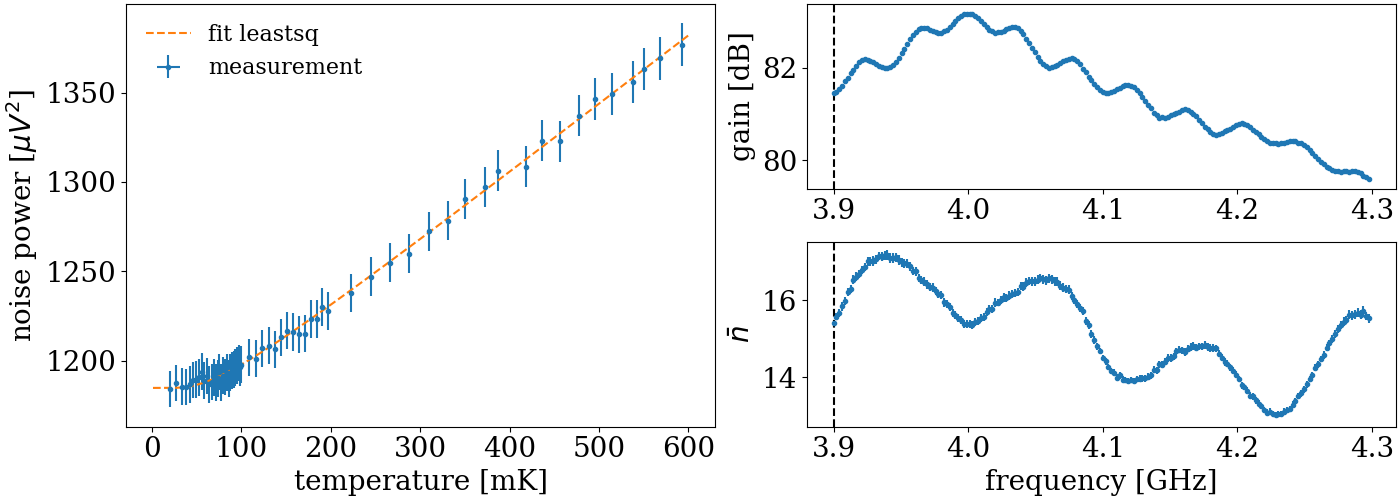

In [6]:
# Thermal noise fit

# Initial guess for fit
G0 = 85
n0 = 5

# initialize empty arrays
gain_arr = np.zeros_like(freq_arr)
gain_std_arr = np.zeros_like(gain_arr)
nbar_arr = np.zeros_like(gain_arr)
nbar_std_arr = np.zeros_like(gain_arr)

# Empty arrays for odr optimization
param = np.zeros((len(gain_arr), 2))
param_std = np.zeros_like(param)

# mixing chamber temperature
temp_mxc = temp_arr
temp_mxc_std = temp_std_arr

for freq_idx, freq_val in enumerate(freq_arr):
    
    # Fit to temperature data using odr
    data = RealData(temp_mxc, noise_uV2[:, freq_idx], temp_mxc_std, noise_uV2_std[:, freq_idx])
    model = Model(lambda beta, temp_mxc: thermal_noise_func_odr(beta, temp_mxc, freq_val, df))
    odr = ODR(data, model, [G0, n0])
    
    # least squares optimization
    odr.set_job(fit_type=2)
    output = odr.run()
    
    # Gain and added noise using leastsq optimization
    gain_arr[freq_idx] = output.beta[0]
    gain_std_arr[freq_idx] = output.sd_beta[0]
    nbar_arr[freq_idx] = output.beta[1]
    nbar_std_arr[freq_idx] = output.sd_beta[1]
    
    # odr (orthogonal distance regression) optimization
    odr.set_job(fit_type=0)
    output = odr.run()
    
    # Gain and added noise using odr optimization
    param[freq_idx] = output.beta
    param_std[freq_idx] = output.sd_beta
    


# Plot — create figure once, update axes on each slider change
fig8 = plt.figure(figsize=(14, 5))
gs8 = gridspec.GridSpec(2, 2, figure=fig8)
ax8 = fig8.add_subplot(gs8[:, 0])
ax8_gain = fig8.add_subplot(gs8[0, 1])
ax8_n = fig8.add_subplot(gs8[1, 1])

def plot_fit(freq_idx_):
    
    gain_val = gain_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 600, 1000)    
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df)  # leastsq
    noise_fit_odr = thermal_noise_func_odr(param[freq_idx_], temp_fit, freq_val, df)  # odr
    
    ax8.cla()
    ax8_gain.cla()
    ax8_n.cla()
    
    # Experimental data
    ax8.errorbar(temp_mxc[:-1], 
                noise_uV2[:-1, freq_idx_], 
                xerr=temp_mxc_std[:-1],
                yerr=noise_uV2_std[:-1, freq_idx_], 
                fmt='.', 
                label='measurement',
               )
    # leastsq fit
    ax8.plot(temp_fit, noise_fit, '--', label='fit leastsq')
    # odr fit
    # ax8.plot(temp_fit, noise_fit_odr, '--', label='fit odr')
    ax8.set_xlabel('temperature [mK]')
    ax8.set_ylabel('noise power [$\\mu V^2$]')
    ax8.legend()
    
    # Gain
    ax8_gain.errorbar(freq_arr[:-1]/1e9, gain_arr[:-1], yerr=gain_std_arr[:-1], fmt='.', label='leastsq')
    # ax8_gain.errorbar(freq_arr[:-1]/1e9, param[:-1, 0], yerr=param_std[:-1, 0], fmt='.', label='odr')
    ax8_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax8_gain.set_ylabel('gain [dB]')
    
    # Added noise
    ax8_n.errorbar(freq_arr[:-1]/1e9, nbar_arr[:-1], yerr=nbar_std_arr[:-1], fmt='.', label='leastsq')
    # ax8_n.errorbar(freq_arr[:-1]/1e9, param[:-1, 1], yerr=param_std[:-1, 1], fmt='.', label='odr')
    ax8_n.axvline(freq_val/1e9, color='black', linestyle='--')
    ax8_n.set_xlabel(r'frequency [GHz]')
    ax8_n.set_ylabel(r'$\bar{n}$')

    fig8.canvas.draw_idle()

    
# Interactive layout  
widgets.interact(plot_fit,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )

/tmp/ipykernel_8305/2883862333.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on the right for the text box


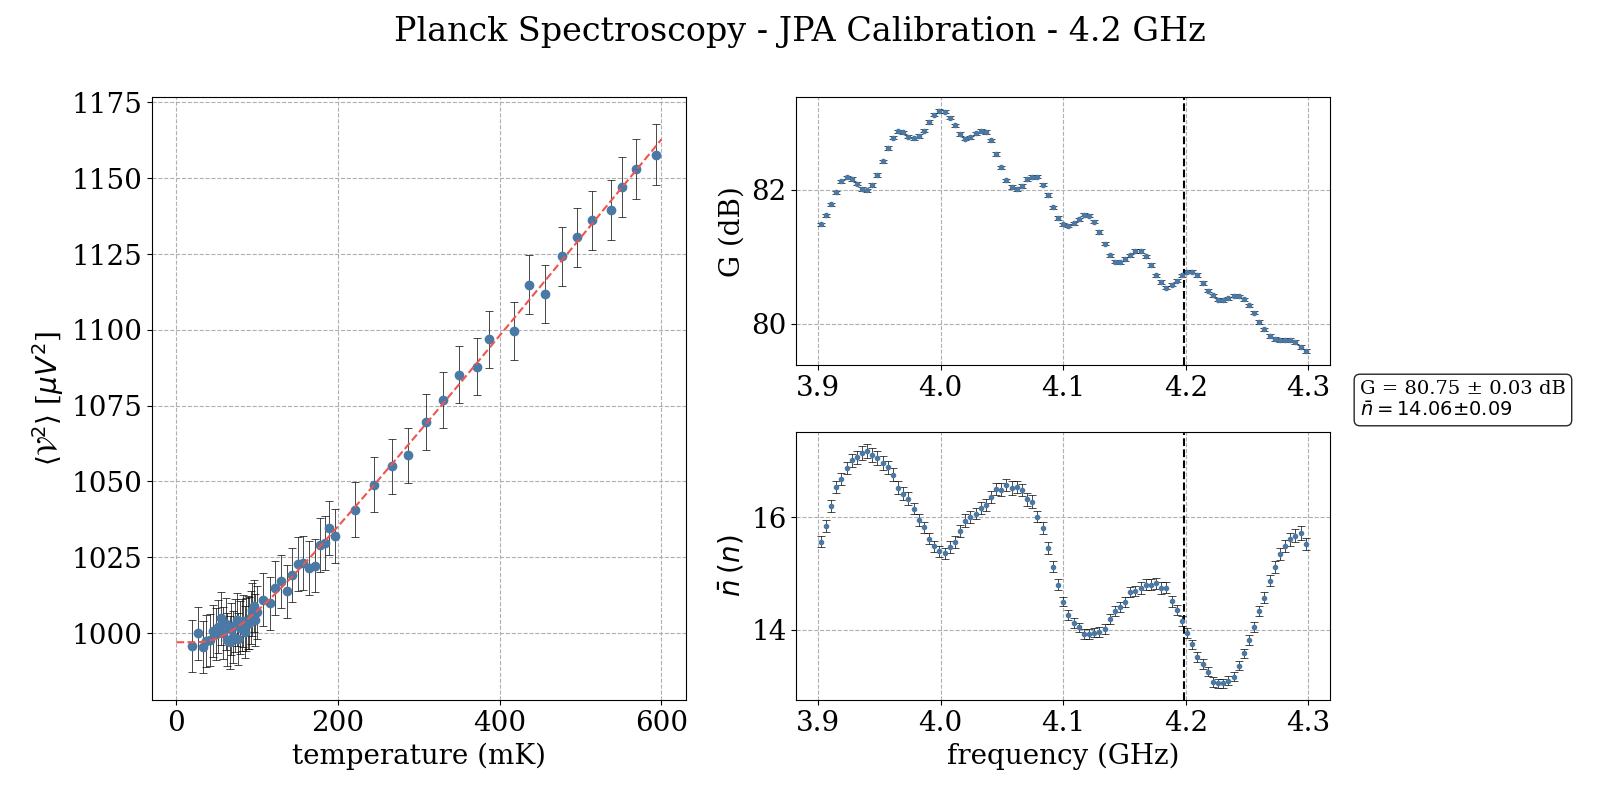

In [ ]:
def plot_fit_single(freq_idx_):
    
    gain_val = gain_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 600, 1000)    
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df)  # leastsq
    
    # Plot fits
    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(2, 2, figure=fig)
    ax = fig.add_subplot(gs[:, 0])
    
    # Experimental data (exclude last temperature point ~852 mK)
    ax.errorbar(temp_mxc[:-1], 
                noise_uV2[:-1, freq_idx_], 
                xerr=temp_mxc_std[:-1],
                yerr=noise_uV2_std[:-1, freq_idx_], 
                fmt='o',
                mfc='#4B79A5',
                c='#4B79A5',
                capsize=3,
                ecolor='black', 
                elinewidth=0.5,
                capthick=0.5,
               )
    # leastsq fit
    ax.plot(temp_fit, noise_fit, '--', c='#ED564E', zorder=2.1)
    ax.set_xlabel('temperature (mK)')
    ax.set_ylabel(r'$\langle \mathcal{V}^2 \rangle$ [$\mu V^2$]')
    ax.grid(True, which='both', ls='--', lw=0.8)
    
    # Gain
    ax_gain = fig.add_subplot(gs[0, 1])
    ax_gain.errorbar(freq_arr[1::2]/1e9, gain_arr[1::2], yerr=gain_std_arr[1::2], fmt='.', c='#4B79A5', capsize=3, ecolor='black', 
                elinewidth=0.5,
                capthick=0.5)
    ax_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax_gain.set_ylabel(r'G (dB)')
    ax_gain.grid(True, which='both', ls='--', lw=0.8)
    # Added noise
    ax_n = fig.add_subplot(gs[1, 1])
    ax_n.errorbar(freq_arr[1::2]/1e9, nbar_arr[1::2], yerr=nbar_std_arr[1::2], fmt='.', c='#4B79A5', capsize=3, ecolor='black', 
                elinewidth=0.5,
                capthick=0.5)
    ax_n.axvline(freq_val/1e9, color='black', linestyle='--', zorder=1.9)
    ax_n.set_xlabel(r'frequency (GHz)')
    ax_n.set_ylabel(r'$\bar{n} \: (n)$')
    ax_n.grid(True, which='both', ls='--', lw=0.8)

    # Plot Title and text box with info
    freq_GHz = np.round(freq_val/1e9, 2)
    fig.suptitle('Planck Spectroscopy - JPA Calibration - {} GHz'.format(freq_GHz))


    info_text = (
    f"G = {gain_val:.2f} ± {gain_std_arr[freq_idx_]:.2f} dB\n"
    f"$\\bar{{n}} = {nbar_val:.2f} ± {nbar_std_arr[freq_idx_]:.2f}$"
)

    fig.text(
    0.85, 0.5,                  # figure coordinates
    info_text,
    ha='left',
    va='center',
    fontsize=14,
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.85
    )
)
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on the right for the text box
    # plt.savefig(
    #     f'Planck Run 2026-04/Figures/JPA Planck/JPA-Planck-2026-04_{freq_GHz}GHz.png',
    #     dpi=300,
    #     bbox_inches='tight'
    # )

plot_fit_single(freq_idx_=142)

interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_photon_number(freq_idx_)>

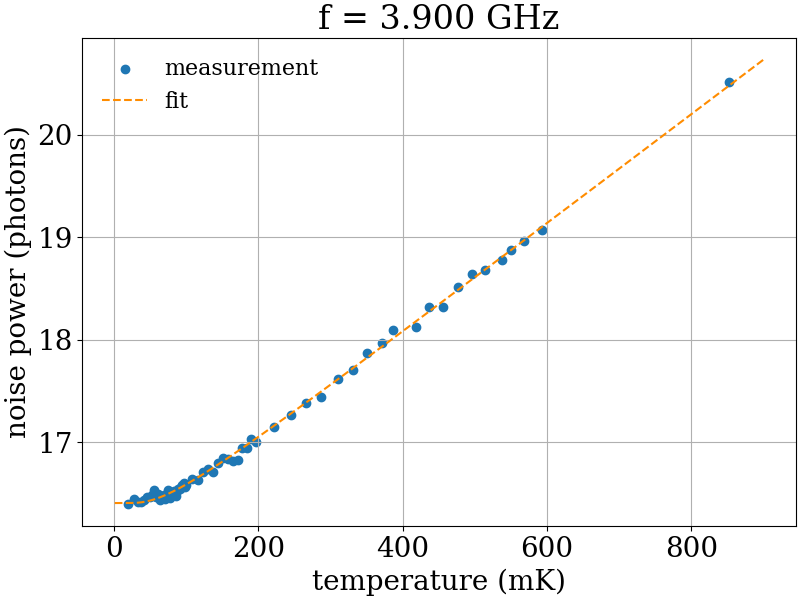

In [ ]:
# Slider plot: noise power in photon number
fig_pn = plt.figure(figsize=(8, 6))
ax_pn = fig_pn.add_subplot(111)

# Parameters for conversion
z_c = 50  #ohms
bw = 1e3  # Hz, integration bandwidth

# Gain in linear scale
def gain_linear(gain_dB):
    return 10 ** (gain_dB / 10)

gain_magnitude = gain_linear(gain_arr)  # Convert gain from dB to linear scale
scale    = 4 * z_c * Planck * bw * 1e12   # Scale factor for converting V^2 to photons

# Convert noise power from uV^2 to number of photons using the relation:
noise_photons = noise_uV2 / (scale * freq_arr * gain_magnitude )  # photons = V^2 / (2 * Zc * hbar * f * df)


def plot_photon_number(freq_idx_):

    gain_val = gain_arr[freq_idx_]
    nbar_val = nbar_arr[freq_idx_]
    freq_val = freq_arr[freq_idx_]


    temp_fit  = np.linspace(1, 900, 1000)
    noise_fit = thermal_noise_func_odr([gain_val, nbar_val], temp_fit, freq_val, df) / (scale * freq_val * gain_linear(gain_val))

    print(f'Gain: {gain_val:.2f} dB, Added noise: {nbar_val:.2f} photons at f = {freq_val/1e9:.3f} GHz')

    ax_pn.cla()

    ax_pn.scatter(temp_mxc,
                   noise_photons[:, freq_idx_],
#                   xerr=temp_mxc_std,
#                   yerr=noise_uV2_std[:, freq_idx_] / (scale * freq_val * gain_linear(gain_val)),
#                   fmt='.',
                   label='measurement',
                  )
    ax_pn.plot(temp_fit, noise_fit, '--', label='fit', color = 'darkorange')
    ax_pn.set_xlabel('temperature (mK)')
    ax_pn.set_ylabel(r'noise power (photons)')
    ax_pn.set_title(f'f = {freq_val/1e9:.3f} GHz')
    ax_pn.legend()
    ax_pn.grid()

    fig_pn.canvas.draw_idle()

    # Save Plot as .png
    # freq_GHz = np.round(freq_val/1e9, 2)
    # plt.savefig(
    #     f'Planck Run 2026-04/Figures/JPA Planck/JPA-Planck-2026-04-photon_{freq_GHz}GHz.png',
    #     dpi=300,
    #     bbox_inches='tight'
    # )

widgets.interact(plot_photon_number,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )


## Temperature correction

In a coaxial cable connecting room temperature electronics to base temperature circuits, thermal photons propagate down the line towards the lower temperature stages. To reduce the spectral density of thermal radiation a series of attenuators is installed in the microwave line. An attenuator with an attenuation of A = 20 dB = 100 eﬀectively acts as a beamsplitter which transmits 1% of the incident signal and adds 99% of blackbody radiation with the eﬀective temperature $T_{att}$ at which the attenuator is thermalized.

The effective temperature $T_i^{eff}$ can be calculated as:

$$ T_i^{eff} = T_{i-1}^{eff} 10^{A_i/10} + T_i \left( 1-10^{A_i/10} \right), $$

where $T_{i-1}^{eff}$ is the effective temperature of the previous temperature stage, $A_i$ represents the attenuation at the current temperature stage, and $T_i$ the measured temperature at the current temperature stage.


The effective temperature is between 1.5 and 2.45 mK higher with respect to the measured by the DR.

In [9]:
# Temperature correction bypassed — using MXC temperature directly.
# When Bluefors logs become available, the cascade correction can be re-enabled here.
# For reference: T_eff ~ T_MXC + ~2.5 mK (constant offset from higher stages),
# which is significant at T_MXC < 50 mK (~4-26% error) but negligible above 200 mK.

temp_mxc_eff     = temp_mxc.copy()
temp_mxc_eff_std = temp_mxc_std.copy()

print('Effective temperature correction bypassed. T_eff = T_MXC.')


Effective temperature correction bypassed. T_eff = T_MXC.


We then repeat the same fit to the thermal noise expression but using the effective temperature of the attenuator instead.

<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8305/298899552.py:86: SyntaxWarning: invalid escape sequence '\m'
  ax13.set_ylabel('noise power [$\mu V^2$]')


interactive(children=(IntSlider(value=0, description='freq ind', max=189), Output()), _dom_classes=('widget-in…

<function __main__.plot_fit(freq_idx_)>

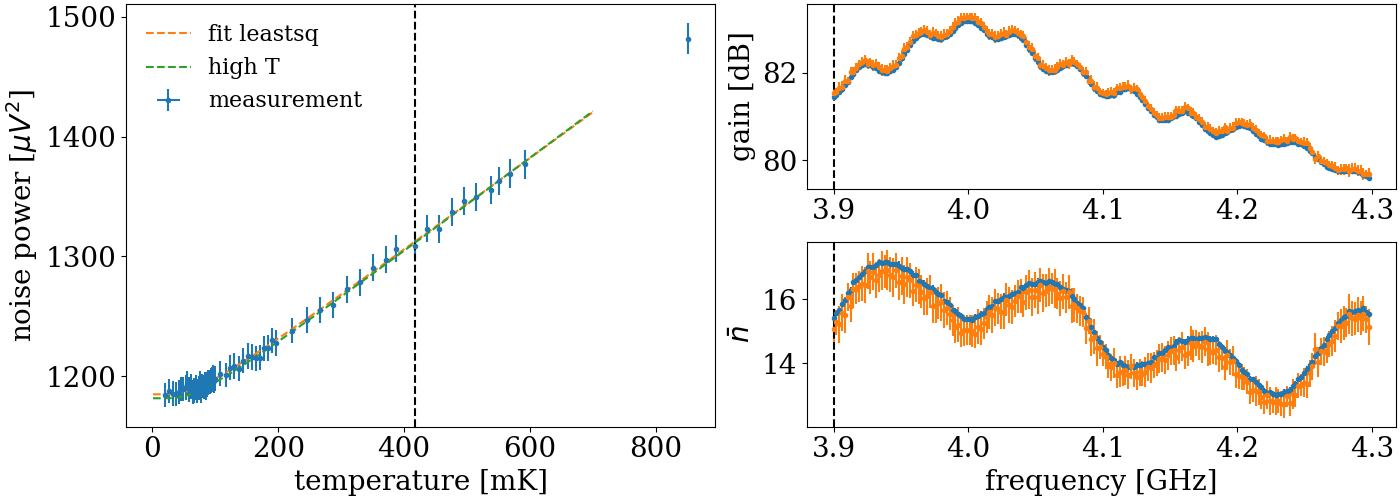

In [10]:
# Thermal noise fit using the effective temperatures

# Initial guess for fit
G0 = 85
n0 = 10

# initialize empty arrays
gain_eff_arr = np.zeros_like(freq_arr)
gain_eff_std_arr = np.zeros_like(gain_eff_arr)
nbar_eff_arr = np.zeros_like(gain_eff_arr)
nbar_eff_std_arr = np.zeros_like(gain_eff_arr)
gn_corr_arr = np.zeros_like(gain_eff_arr)

# Empty arrays for odr optimization
param_eff = np.zeros((len(gain_eff_arr), 2))
param_eff_std = np.zeros_like(param_eff)

for freq_idx, freq_val in enumerate(freq_arr):
    
    # Fit to temperature data using curve_fit
    popt, pcov = curve_fit(lambda temp_mxc_eff, Gsignal, n: thermal_noise_func(temp_mxc_eff, Gsignal, n, freq_val, df),
                           temp_mxc_eff,
                           noise_uV2[:, freq_idx],
                           p0=(G0, n0),
                           sigma=noise_uV2_std[:, freq_idx],
                           )
    
    # Gain and added noise using leastsq optimization
    gain_eff_arr[freq_idx] = popt[0]
    nbar_eff_arr[freq_idx] = popt[1]
    perr = np.sqrt(np.diag(pcov))
    gain_eff_std_arr[freq_idx] = perr[0]
    nbar_eff_std_arr[freq_idx] = perr[1]
    gn_corr_arr[freq_idx] = pcov[0,1]
    
    # Fit to temperature data using odr
    temp_cutoff = -11
    data = RealData(temp_mxc_eff[temp_cutoff:], noise_uV2[temp_cutoff:, freq_idx], temp_mxc_eff_std[temp_cutoff:], noise_uV2_std[temp_cutoff:, freq_idx])
    model = Model(lambda beta, temp_mxc_eff: thermal_noise_func_odr(beta, temp_mxc_eff, freq_val, df))
    odr = ODR(data, model, [G0, n0])
    
    # odr optimization (least square method)
    odr.set_job(fit_type=2)
    output = odr.run()
    
    # Gain and added noise using odr optimization
    param_eff[freq_idx] = output.beta
    param_eff_std[freq_idx] = output.sd_beta


# Plot — create figure once, update axes on each slider change
fig13 = plt.figure(figsize=(14, 5))
gs13 = gridspec.GridSpec(2, 2, figure=fig13)
ax13 = fig13.add_subplot(gs13[:, 0])
ax13_gain = fig13.add_subplot(gs13[0, 1])
ax13_n = fig13.add_subplot(gs13[1, 1])

def plot_fit(freq_idx_):
    
    gain_val = gain_eff_arr[freq_idx_]  # Gain at a given frequency
    nbar_val = nbar_eff_arr[freq_idx_]  # Added noise at a given freq
    freq_val = freq_arr[freq_idx_]  # Given frequency
    
    # Temperature range for fitting
    temp_fit = np.linspace(1, 700, 1000)
    noise_fit = thermal_noise_func(temp_fit, gain_val, nbar_val, freq_val, df)  # leastsq
    noise_fit_odr = thermal_noise_func_odr(param_eff[freq_idx_], temp_fit, freq_val, df)  # least square but only high T
    
    ax13.cla()
    ax13_gain.cla()
    ax13_n.cla()
    
    ax13.errorbar(temp_mxc_eff, 
                noise_uV2[:, freq_idx_],
                xerr=temp_mxc_eff_std,
                yerr=noise_uV2_std[:, freq_idx_], 
                fmt='.', 
                label='measurement',
               )
    # leastsq fit
    ax13.plot(temp_fit, noise_fit, '--', label='fit leastsq')
    # odr fit
    ax13.plot(temp_fit, noise_fit_odr, '--', label='high T')
    ax13.axvline(temp_mxc_eff[temp_cutoff], ls='--', c='black')
    ax13.set_xlabel('temperature [mK]')
    ax13.set_ylabel('noise power [$\mu V^2$]')
    ax13.legend()
    
    # Gain
    ax13_gain.errorbar(freq_arr[:-1]/1e9, gain_eff_arr[:-1], yerr=gain_eff_std_arr[:-1], fmt='.', label='leastsq')
    ax13_gain.errorbar(freq_arr[:-1]/1e9, param_eff[:-1, 0], yerr=param_eff_std[:-1, 0], fmt='.', label='high T')
    ax13_gain.axvline(freq_val/1e9, color='black', linestyle='--')
    ax13_gain.set_ylabel('gain [dB]')
    
    # Added noise
    ax13_n.errorbar(freq_arr[:-1]/1e9, nbar_eff_arr[:-1], yerr=nbar_eff_std_arr[:-1], fmt='.', label='leastsq')
    ax13_n.errorbar(freq_arr[:-1]/1e9, param_eff[:-1, 1], yerr=param_eff_std[:-1, 1], fmt='.', label='high T')
    ax13_n.axvline(freq_val/1e9, color='black', linestyle='--')
    ax13_n.set_xlabel(r'frequency [GHz]')
    ax13_n.set_ylabel(r'$\bar{n}$')

    fig13.canvas.draw_idle()

# Interactive layout  
widgets.interact(plot_fit,
                 freq_idx_=widgets.IntSlider(min=0,
                                             max=len(freq_arr)-2,
                                             step=1,
                                             description='freq ind',
                                             )
                )

We plot the difference between the gain and added number of photons between using the effective temperatures and the directly measured ones.

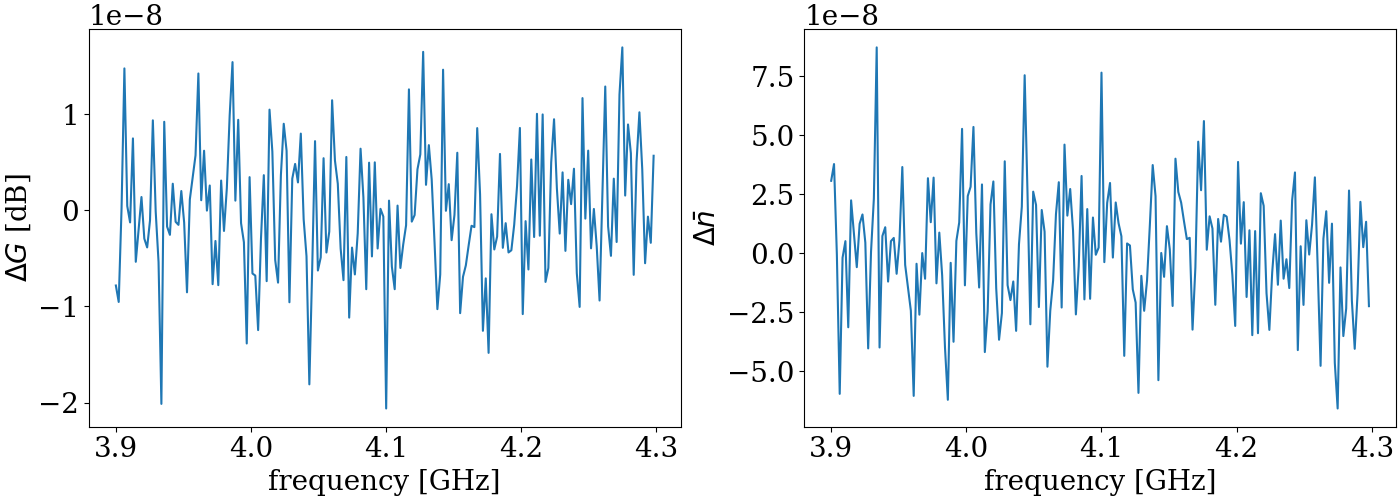

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(freq_arr[:-1]/1e9, gain_eff_arr[:-1]-gain_arr[:-1])
ax[0].set_xlabel(r'frequency [GHz]')
ax[0].set_ylabel(r'$\Delta G$ [dB]')

ax[1].plot(freq_arr[:-1]/1e9, nbar_eff_arr[:-1]-nbar_arr[:-1])
ax[1].set_xlabel(r'frequency [GHz]')
ax[1].set_ylabel(r'$\Delta \bar{n}$')

plt.show()

We now save the gain $G$ and added number of photons $\bar{n}$ as a function of frequency.

In [12]:
# Open the save file (.hdf5) in append mode
save = False

if save:
    
    with h5py.File(file, "a") as dataset:

        # String as handles
        gain_data_str = "{}/gain".format(run)
        std_gain_data_str = "{}/std gain".format(run)
        n_data_str = "{}/n".format(run)
        std_n_data_str = "{}/std n".format(run)
        std_gn_data_str = "{}/std g-n".format(run)

        # Write data to datasets
        dataset.create_dataset(gain_data_str, (np.shape(gain_eff_arr)),
                               dtype=float, data=gain_eff_arr)
        dataset.create_dataset(std_gain_data_str, (np.shape(gain_eff_std_arr)),
                               dtype=float, data=gain_eff_std_arr)
        dataset.create_dataset(n_data_str, (np.shape(nbar_eff_arr)),
                               dtype=float, data=nbar_eff_arr)
        dataset.create_dataset(std_n_data_str, (np.shape(nbar_eff_std_arr)),
                               dtype=float, data=nbar_eff_std_arr)
        dataset.create_dataset(std_gn_data_str, (np.shape(gn_corr_arr)),
                               dtype=float, data=gn_corr_arr)

        # Write dataset attributes
        dataset[gain_data_str].attrs["Unit"] = "dB"
        dataset[std_gain_data_str].attrs["Unit"] = "dB"
        dataset[n_data_str].attrs["Unit"] = "n"
        dataset[std_n_data_str].attrs["Unit"] = "n"
        dataset[std_gn_data_str].attrs["Unit"] = "n"
